# 06 - Fuentes externas y contexto territorial

**Objetivo.** Incorporar fuentes externas de CABA y dejar resuelta su unión con la base inmobiliaria, a tres niveles:

| Nivel | Unidades | Llave de unión | Fuentes |
|---|---|---|---|
| Publicación | ~68.000 avisos | coordenadas (Airbnb propias; MeLi y ArgenProp geocodificadas con USIG) | transporte, servicios, cultura, verdes |
| Barrio | 48 | polígono oficial de barrio | conteos y densidades de las fuentes puntuales |
| Comuna | 15 | número de comuna | Censo 2022 |

Este notebook documenta cada fuente (cobertura, período, granularidad, mecanismo de unión, variable derivada, hipótesis a la que aporta y limitaciones), verifica su calidad real y genera las llaves territoriales. Las variables derivadas por publicación y los KPIs se construyen en el notebook 07.

**Cambios respecto de la versión anterior de este notebook.** La versión previa cargaba las fuentes de BA Data con `pd.read_csv(url)`. El portal rechaza esos pedidos ("Request Rejected") y el código seguía adelante sin avisar, por lo que las 9 fuentes quedaban con 0 filas y todas las variables de contexto por barrio salían vacías. Ahora las fuentes se descargan una vez a `data/raw/externas/` (con fecha y checksum) y se leen desde ese snapshot. Además, cinco recursos traen la ubicación como geometría WKT, tres de ellos en metros, y no como columnas `lat`/`lon`; se agregaron cargadores específicos por fuente.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontró la raíz del repo. Ejecutar dentro del proyecto.')


sys.path.insert(0, str(find_repo_root()))
from src import config, externas, geo, usig
from src import features as F

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#52514e', 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e',
                     'ytick.color': '#52514e', 'font.size': 9})
COLORES_OPERACION = {'venta': '#2a78d6', 'alquiler': '#eb6834', 'alquiler_temporal': '#1baf7a'}

print('Repo:', config.REPO_ROOT)
print('Snapshots externos:', config.EXTERNAS_RAW_DIR.relative_to(config.REPO_ROOT))

Repo: /Users/juancruzmoyano/Proyectos/TP_analitica_descriptiva_grupo1_2q2026
Snapshots externos: data/raw/externas


## 1. Snapshot de las fuentes

`descargar_fuentes()` solo descarga lo que todavía no existe en `data/raw/externas/`. Con el snapshot presente no hay llamadas de red, así que el notebook se reproduce igual aunque el portal cambie un recurso. La fecha de descarga es la fecha de corte de cada fuente externa.

In [2]:
snapshot = externas.descargar_fuentes()
display(snapshot[['fuente', 'estado', 'archivo', 'fecha_descarga_utc', 'bytes']])
assert snapshot['estado'].str.startswith('error').sum() == 0, 'Hay fuentes sin snapshot'

,fuente,estado,archivo,fecha_descarga_utc,bytes
0,subte_estaciones,snapshot existente,subte_estaciones.csv,2026-10-04T23:03:34+00:00,5990
1,estaciones_ferrocarril,snapshot existente,estaciones_ferrocarril.csv,2026-10-04T23:03:35+00:00,35537
2,metrobus,snapshot existente,metrobus.csv,2026-10-04T23:03:35+00:00,58273
3,hospitales,snapshot existente,hospitales.csv,2026-10-04T23:03:36+00:00,15608
4,educacion,snapshot existente,educacion.csv,2026-10-04T23:03:37+00:00,1141705
5,espacios_culturales,snapshot existente,espacios_culturales.csv,2026-10-04T23:03:39+00:00,724491
6,gastronomia,snapshot existente,gastronomia.csv,2026-10-04T23:03:40+00:00,438717
7,espacios_verdes,snapshot existente,espacios_verdes.csv,2026-10-04T23:03:54+00:00,15170492
8,bibliotecas,snapshot existente,bibliotecas.csv,2026-10-04T23:03:55+00:00,21846
9,subte_pasajeros,snapshot existente,subte_pasajeros.csv,2026-10-04T23:03:56+00:00,831


## 2. Inventario documentado

Cada fuente priorizada se documenta con los campos que exige la consigna. La columna `explica_intra_comuna` es el criterio de compatibilidad con la unidad de análisis: una fuente agregada por comuna no puede explicar diferencias entre barrios de una misma comuna.

In [3]:
PERIODO_BA = 'Snapshot vigente a la descarga (ver tabla anterior)'
UNION_PUNTUAL = 'Distancia/conteo desde coordenadas de la publicación; punto en polígono de barrio para densidades'

inventario = pd.DataFrame([
    ['F01', 'Censo 2022 - población, superficie, viviendas, hogares, tenencia (INDEC, 6 cuadros)', 'CABA, 15 comunas', '2022 (datos definitivos)', 'Comuna', 'Por número de comuna', 'poblacion_total, viviendas_*, hogares, tamano_medio_hogar, pct_hogares_inquilinos, pct_viviendas_uso_temporal', 'Denominadores por habitante/vivienda/hogar; H1, H2a, H4', 'Solo 15 unidades; no distingue barrios; foto 2022 vs avisos 2026', 'No'],
    ['F02', 'Estaciones de subte (BA Data)', 'Red de subte, CABA', PERIODO_BA, 'Punto (90 estaciones)', UNION_PUNTUAL, 'dist_subte_m; n_subte por barrio', 'H3; control de accesibilidad en H1, H2b, H4', 'Distancia en línea recta; no mide frecuencia', 'Sí'],
    ['F03', 'Estaciones de ferrocarril (BA Data)', 'Red metropolitana; se usan todas para distancias y solo las de CABA para conteos', PERIODO_BA, 'Punto (301 estaciones, 43 en CABA)', UNION_PUNTUAL, 'dist_tren_m; n_tren por barrio', 'H3', 'No mide frecuencia ni ramal', 'Sí'],
    ['F04', 'Paradas de MetroBus (BA Data)', 'Corredores de CABA', PERIODO_BA, 'Punto (390 paradas)', UNION_PUNTUAL, 'dist_metrobus_m; n_metrobus por barrio', 'H3', 'Cobertura territorial acotada a los corredores', 'Sí'],
    ['F05', 'Hospitales públicos (BA Data)', 'CABA', PERIODO_BA, 'Punto (36)', UNION_PUNTUAL, 'dist_hospitales_m; n_hospitales por barrio', 'H2b', 'Solo hospitales públicos; no mide capacidad', 'Sí'],
    ['F06', 'Establecimientos educativos (BA Data)', 'CABA', PERIODO_BA, 'Punto; se usan inicial, primario y secundario común (1.627 de 2.767)', UNION_PUNTUAL, 'n_educacion_500m; n_educacion por barrio', 'H2b', 'Mide oferta, no calidad ni vacantes', 'Sí'],
    ['F07', 'Espacios culturales (BA Data)', 'CABA', PERIODO_BA, 'Punto (3.053) con categoría', UNION_PUNTUAL, 'n_culturales_500m; densidad por barrio', 'H1, H2b', 'Mezcla categorías (incluye bares y librerías); correlaciona con centralidad', 'Sí'],
    ['F08', 'Gastronomía de interés turístico (BA Data)', 'CABA', PERIODO_BA, 'Punto (2.823)', UNION_PUNTUAL, 'n_gastronomia_500m; densidad por barrio', 'H1; control de atractivo en H4', 'Solo prestadores registrados, no el universo gastronómico', 'Sí'],
    ['F09', 'Espacios verdes (BA Data)', 'CABA', PERIODO_BA, 'Polígono; se usan plazas, parques y jardines (485 de 2.176)', 'Distancia al borde (vértices) y superficie por barrio', 'dist_espacio_verde_m; pct_superficie_verde por barrio', 'H1, H2b', 'Se excluyen canteros, plazoletas y patios', 'Sí'],
    ['F10', 'GeoJSON de barrios (GCBA)', 'CABA, 48 barrios', PERIODO_BA, 'Polígono', 'Punto en polígono', 'barrio_oficial, comuna, area_km2', 'Habilita todas las uniones por barrio', 'Límites vigentes; puntos sobre el borde pueden quedar afuera', 'Sí'],
    ['F11', 'USIG - geocodificador de direcciones (GCBA)', 'CABA', 'Consultado el 04/10/2026 (fecha en la caché)', 'Dirección -> punto', 'Calle y altura o intersección del aviso', 'lat, lon, metodo_geo', 'Habilita H3 para MeLi y ArgenProp', 'Requiere calle y altura; ZonaProp no trae dirección', 'Sí'],
    ['F12', 'Dólar MEP diario (ArgentinaDatos)', 'Nacional', 'Serie diaria; se usa ago-sep 2026', 'Día', 'Por fecha de extracción del aviso', 'tc_mep, precio_*_usd', 'Todos los KPIs de precio', 'Una sola cotización por día', 'No aplica'],
], columns=['id', 'fuente', 'cobertura_geografica', 'periodo', 'granularidad', 'mecanismo_union',
            'variable_derivada', 'aporta_a', 'limitaciones', 'explica_intra_comuna'])

descartadas = pd.DataFrame([
    ['Bibliotecas (BA Data)', 'Ya incluidas en espacios culturales (619 registros con función BIBLIOTECA)'],
    ['Pasajeros de subte (BA Data)', 'Solo por línea y año (48 filas): no distingue estaciones'],
], columns=['fuente', 'motivo_descarte'])

display(inventario)
display(descartadas)
inventario.to_csv(config.PROCESSED_DIR / 'fuentes_externas_inventario_v1.csv', index=False)

,id,fuente,cobertura_geografica,periodo,granularidad,mecanismo_union,variable_derivada,aporta_a,limitaciones,explica_intra_comuna
0,F01,"Censo 2022 - población, superficie, viviendas,...","CABA, 15 comunas",2022 (datos definitivos),Comuna,Por número de comuna,"poblacion_total, viviendas_*, hogares, tamano_...",Denominadores por habitante/vivienda/hogar; H1...,Solo 15 unidades; no distingue barrios; foto 2...,No
1,F02,Estaciones de subte (BA Data),"Red de subte, CABA",Snapshot vigente a la descarga (ver tabla ante...,Punto (90 estaciones),Distancia/conteo desde coordenadas de la publi...,dist_subte_m; n_subte por barrio,"H3; control de accesibilidad en H1, H2b, H4",Distancia en línea recta; no mide frecuencia,Sí
2,F03,Estaciones de ferrocarril (BA Data),Red metropolitana; se usan todas para distanci...,Snapshot vigente a la descarga (ver tabla ante...,"Punto (301 estaciones, 43 en CABA)",Distancia/conteo desde coordenadas de la publi...,dist_tren_m; n_tren por barrio,H3,No mide frecuencia ni ramal,Sí
3,F04,Paradas de MetroBus (BA Data),Corredores de CABA,Snapshot vigente a la descarga (ver tabla ante...,Punto (390 paradas),Distancia/conteo desde coordenadas de la publi...,dist_metrobus_m; n_metrobus por barrio,H3,Cobertura territorial acotada a los corredores,Sí
4,F05,Hospitales públicos (BA Data),CABA,Snapshot vigente a la descarga (ver tabla ante...,Punto (36),Distancia/conteo desde coordenadas de la publi...,dist_hospitales_m; n_hospitales por barrio,H2b,Solo hospitales públicos; no mide capacidad,Sí
5,F06,Establecimientos educativos (BA Data),CABA,Snapshot vigente a la descarga (ver tabla ante...,"Punto; se usan inicial, primario y secundario ...",Distancia/conteo desde coordenadas de la publi...,n_educacion_500m; n_educacion por barrio,H2b,"Mide oferta, no calidad ni vacantes",Sí
6,F07,Espacios culturales (BA Data),CABA,Snapshot vigente a la descarga (ver tabla ante...,Punto (3.053) con categoría,Distancia/conteo desde coordenadas de la publi...,n_culturales_500m; densidad por barrio,"H1, H2b",Mezcla categorías (incluye bares y librerías);...,Sí
7,F08,Gastronomía de interés turístico (BA Data),CABA,Snapshot vigente a la descarga (ver tabla ante...,Punto (2.823),Distancia/conteo desde coordenadas de la publi...,n_gastronomia_500m; densidad por barrio,H1; control de atractivo en H4,"Solo prestadores registrados, no el universo g...",Sí
8,F09,Espacios verdes (BA Data),CABA,Snapshot vigente a la descarga (ver tabla ante...,"Polígono; se usan plazas, parques y jardines (...",Distancia al borde (vértices) y superficie por...,dist_espacio_verde_m; pct_superficie_verde por...,"H1, H2b","Se excluyen canteros, plazoletas y patios",Sí
9,F10,GeoJSON de barrios (GCBA),"CABA, 48 barrios",Snapshot vigente a la descarga (ver tabla ante...,Polígono,Punto en polígono,"barrio_oficial, comuna, area_km2",Habilita todas las uniones por barrio,Límites vigentes; puntos sobre el borde pueden...,Sí


,fuente,motivo_descarte
0,Bibliotecas (BA Data),Ya incluidas en espacios culturales (619 regis...
1,Pasajeros de subte (BA Data),Solo por línea y año (48 filas): no distingue ...


## 3. Perfilado de las fuentes puntuales

Antes de unir, se verifica con los datos lo que afirma el inventario: cantidad de puntos, sistema de coordenadas de origen y porcentaje de puntos que cae dentro de algún barrio oficial.

In [4]:
barrios = geo.cargar_barrios(config.EXTERNAS_RAW_DIR / 'barrios.geojson')
print(f'Barrios oficiales: {len(barrios)} | superficie total: {barrios["area_km2"].sum():.1f} km2')

fuentes = externas.cargar_todas_las_fuentes_puntuales()
SISTEMA_ORIGEN = {'subte': 'WKT grados', 'tren': 'WKT grados', 'metrobus': 'X/Y grados',
                  'hospitales': 'WKT metros (Gauss-Krüger BA)', 'educacion': 'WKT metros (Gauss-Krüger BA)',
                  'culturales': 'lat/long grados', 'gastronomia': 'lat/long con coma decimal',
                  'espacios_verdes': 'MULTIPOLYGON grados'}

perfil = []
for nombre, p in fuentes.items():
    barrio_punto = geo.asignar_barrio(p['lat'], p['lon'], barrios)
    fuentes[nombre] = p.assign(barrio_oficial=barrio_punto.values)
    perfil.append({'fuente': nombre, 'puntos': len(p), 'formato_origen': SISTEMA_ORIGEN[nombre],
                   'pct_coords_validas': round(p[['lat', 'lon']].notna().all(axis=1).mean() * 100, 1),
                   'pct_dentro_de_caba': round(barrio_punto.notna().mean() * 100, 1),
                   'barrios_con_al_menos_uno': barrio_punto.nunique()})
perfil = pd.DataFrame(perfil)
display(perfil)
perfil.to_csv(config.REPORTS_DIR / 'perfil_fuentes_externas.csv', index=False)

Barrios oficiales: 48 | superficie total: 204.0 km2


,fuente,puntos,formato_origen,pct_coords_validas,pct_dentro_de_caba,barrios_con_al_menos_uno
0,subte,90,WKT grados,100.0,100.0,20
1,tren,301,WKT grados,100.0,14.3,27
2,metrobus,390,X/Y grados,100.0,100.0,33
3,hospitales,36,WKT metros (Gauss-Krüger BA),100.0,100.0,19
4,educacion,1627,WKT metros (Gauss-Krüger BA),100.0,100.0,48
5,culturales,3053,lat/long grados,99.3,99.3,48
6,gastronomia,2823,lat/long con coma decimal,100.0,100.0,47
7,espacios_verdes,485,MULTIPOLYGON grados,100.0,100.0,48


**Lectura.** Todas las fuentes quedan con coordenadas válidas tras convertir los tres formatos distintos. El control de que la conversión desde metros es correcta es que hospitales y escuelas caen dentro de CABA en más del 97% de los casos (un error de proyección los dejaría fuera; además, las escuelas caen en el barrio que declaran en el 100% de los casos). El tren es la excepción esperada: solo 43 de 301 estaciones están en CABA; para distancias se usan todas, porque una vivienda cerca de la General Paz puede tener la estación más próxima del otro lado, pero para conteos por barrio solo cuentan las de CABA. El subte y el MetroBus no llegan a todos los barrios, lo que anticipa que la densidad de transporte por barrio va a tener muchos ceros.

## 4. Censo 2022 por comuna

Se integran seis cuadros de los resultados definitivos para CABA. Además de población y superficie (el único cuadro que usaba la versión anterior), se suman viviendas por condición de ocupación, hogares, tipo de vivienda y régimen de tenencia. Los totales se validan contra el total de la Ciudad dentro de `cargar_censo_comunas()`.

In [5]:
censo = externas.cargar_censo_comunas()
cols_censo_vista = ['comuna', 'poblacion_total', 'viviendas_particulares', 'hogares', 'tamano_medio_hogar',
                    'pct_hogares_inquilinos', 'pct_viviendas_departamento', 'pct_viviendas_uso_temporal',
                    'pct_viviendas_en_alquiler_o_venta']
display(censo[cols_censo_vista].round(2))
censo.to_csv(config.PROCESSED_DIR / 'censo_2022_comunas_v1.csv', index=False)

,comuna,poblacion_total,viviendas_particulares,hogares,tamano_medio_hogar,pct_hogares_inquilinos,pct_viviendas_departamento,pct_viviendas_uso_temporal,pct_viviendas_en_alquiler_o_venta
0,1,223554,130145,106509,2.07,48.33,76.84,1.29,4.98
1,2,161645,107498,83818,1.92,41.31,96.55,2.96,4.49
2,3,196240,110264,92555,2.09,47.93,83.97,0.67,4.92
3,4,229240,100950,91186,2.49,34.49,55.34,0.21,2.98
4,5,194271,105979,93208,2.06,41.26,82.81,0.37,4.18
5,6,203043,106669,95464,2.11,35.27,86.67,0.36,4.13
6,7,215896,99624,90970,2.34,33.97,67.65,0.16,3.82
7,8,204367,73029,70622,2.89,25.72,40.20,0.05,1.27
8,9,169063,75315,66753,2.52,29.95,44.43,0.26,3.39
9,10,173004,84220,73964,2.32,30.89,54.94,0.28,3.70


**Lectura.** Las comunas 1, 2 y 14 (centro, Recoleta y Palermo) concentran la mayor proporción de viviendas destinadas a uso temporal: entre 1,2% y 3% de sus viviendas particulares, contra menos de 0,3% en la mayoría del sur y oeste. Es el mismo patrón que H1 y H4 esperan para el alquiler temporario, medido con una fuente independiente de los portales. La comuna 8 está en el otro extremo: hogares más grandes (2,9 personas), menos inquilinos (26%) y casi sin viviendas temporales ni desocupadas en oferta.

**Proxy para H2a.** El Censo no publica hogares unipersonales por comuna. Se usa `tamano_medio_hogar` (población en viviendas particulares / hogares): un tamaño medio menor implica, en promedio, más hogares de una o dos personas. No es equivalente: dos comunas con igual promedio pueden tener composiciones distintas.

## 5. Llaves territoriales de la base inmobiliaria

Se parte de la base consolidada del notebook 04. Para cada publicación se determina el barrio oficial a partir del texto declarado por el portal: coincidencia con los 48 nombres oficiales, equivalencias inequívocas de sub-barrios ("Belgrano R" -> Belgrano, "Las Cañitas" -> Palermo) o, si la denominación abarca más de un barrio ("Congreso", "Abasto"), sin asignar.

In [6]:
base = pd.read_csv(config.BASE_CONSOLIDADA, low_memory=False, dtype={'id_publicacion': str})
CLAVE = ['id_publicacion', 'tipo_operacion_norm']
assert not base.duplicated(CLAVE).any(), 'La clave publicación-operación debe ser única'
print('Base:', config.BASE_CONSOLIDADA.name, base.shape)

barrio_texto, estado_texto = F.barrio_desde_texto(base['barrio_norm'], barrios['barrio_oficial'])
tabla_texto = pd.crosstab(base['fuente_norm'], estado_texto, margins=True, margins_name='total')
display(tabla_texto)

Base: df_publicaciones_consolidadas_con_outliers_v1.csv (67887, 100)


col_0,ambiguo,equivalencia,fuera_de_caba,no_reconocido,oficial,sin_dato,total
fuente_norm,,,,,,,
airbnb,0,0,0,0,9519,77,9596
argenprop,1,0,1,160,0,0,162
mercado_libre,51,355,16,7,56520,200,57149
zonaprop,8,84,0,1,887,0,980
total,60,439,17,168,66926,277,67887


**Lectura.** En Mercado Libre, ZonaProp y Airbnb el barrio declarado se resuelve casi siempre. ArgenProp es un caso particular: sus 162 avisos tienen en `barrio_norm` el nombre de la calle ("suipacha", "avenida santa fe"), un arrastre del notebook 02, así que su barrio solo puede obtenerse por geocodificación. Hay 17 avisos que declaran una localidad fuera de CABA (La Plata, Mar del Plata, Rosario, entre otras). Los que tampoco tienen coordenadas dentro de la Ciudad quedan marcados como fuera de alcance (ver tabla de cobertura más abajo).

## 6. Geocodificación con USIG

Mercado Libre, ZonaProp y ArgenProp no publican coordenadas. Se geocodificaron las direcciones con los servicios de USIG (GCBA) mediante `src/usig.py`:

1. **Limpieza** del texto de dirección: se quitan sufijos de unidad ("- Unidad 4A"), referencias de cuadra ("Entre ..."), piso y el conector "Al" de Mercado Libre; si falta la altura se toma del texto; sin altura, se interpreta como intersección.
2. **Consulta** de cada dirección única: calle y altura contra el servicio REST (devuelve coordenadas Gauss-Krüger, convertidas a grados) e intersecciones contra el normalizador.
3. **Caché** en `data/processed/geocodificacion_usig_cache.csv`. Esta celda solo consulta lo que falte en la caché; con la caché completa no hay llamadas de red.

La corrida completa se hizo una vez con `python -m src.usig`.

In [7]:
no_airbnb = base['fuente_norm'] != 'airbnb'
consultas = usig.preparar_consultas(base.loc[no_airbnb].copy())
cache = usig.geocodificar_lote(consultas)

resumen_cache = (cache.assign(resultado=np.where(cache['estado'] == 'ok', 'geocodificada', 'sin geocodificar'))
                 .groupby(['tipo', 'resultado']).size().unstack(fill_value=0))
display(resumen_cache)
display(cache.loc[cache['estado'] != 'ok', 'estado'].value_counts().rename('consultas').to_frame())

Consultas únicas: 23359 | en caché: 23359 | pendientes: 0


resultado,geocodificada,sin geocodificar
tipo,,
calle_altura,20089,2877
interseccion,287,106


,consultas
estado,
ErrorCalleInexistenteAEsaAltura,1422
ErrorCalleInexistente,969
Ambiguedad,300
ErrorInput,167
sin_resultado,125


In [8]:
# Unión de la caché a cada publicación.
claves = base.loc[no_airbnb, ['calle', 'altura']].copy()
usig.preparar_consultas(claves)
ubicacion = base[CLAVE + ['fuente_norm']].copy()
ubicacion['geo_clave'] = claves['geo_clave']
ubicacion = ubicacion.merge(cache.loc[cache['estado'] == 'ok', ['clave', 'lat', 'lon', 'metodo']],
                            left_on='geo_clave', right_on='clave', how='left').drop(columns='clave')

# Airbnb trae coordenadas propias (ofuscadas por la plataforma; ver limitaciones).
es_airbnb = base['fuente_norm'].eq('airbnb').to_numpy()
ubicacion.loc[es_airbnb, 'lat'] = pd.to_numeric(base.loc[es_airbnb, 'latitud'], errors='coerce').to_numpy()
ubicacion.loc[es_airbnb, 'lon'] = pd.to_numeric(base.loc[es_airbnb, 'longitud'], errors='coerce').to_numpy()
ubicacion.loc[es_airbnb, 'metodo'] = 'airbnb_coordenadas_propias'
ubicacion = ubicacion.rename(columns={'metodo': 'metodo_geo'})

ubicacion['barrio_punto'] = geo.asignar_barrio(ubicacion['lat'], ubicacion['lon'], barrios).values
ubicacion['barrio_texto'] = barrio_texto.values
ubicacion['estado_barrio_texto'] = estado_texto.values

### 6.1 Validación: barrio del punto vs barrio declarado

Si la geocodificación es correcta, el barrio del polígono debería coincidir con el que declara el aviso en la gran mayoría de los casos. Las discrepancias esperables son avisos en el límite entre barrios y avisos que declaran un barrio "de marketing" vecino (por ejemplo, Palermo para viviendas de Villa Crespo). Discrepancias masivas en un método indicarían un error.

In [9]:
comparables = ubicacion.dropna(subset=['barrio_punto', 'barrio_texto'])
concordancia = (comparables.assign(coincide=comparables['barrio_punto'] == comparables['barrio_texto'])
                .groupby('metodo_geo')['coincide'].agg(publicaciones='size', pct_coincide='mean'))
concordancia['pct_coincide'] = (concordancia['pct_coincide'] * 100).round(1)
display(concordancia)

pares = (comparables[comparables['barrio_punto'] != comparables['barrio_texto']]
         .groupby(['barrio_texto', 'barrio_punto']).size().sort_values(ascending=False).head(10)
         .rename('publicaciones').reset_index())
display(pares)

,publicaciones,pct_coincide
metodo_geo,,
airbnb_coordenadas_propias,9519,99.9
normalizar_interseccion,868,78.6
rest_calle_altura,47548,81.8
rest_calle_altura_recortada,1209,58.1


,barrio_texto,barrio_punto,publicaciones
0,Recoleta,Retiro,401
1,Belgrano,Palermo,312
2,Puerto Madero,Monserrat,303
3,San Telmo,Constitucion,296
4,Palermo,Recoleta,289
5,Belgrano,Colegiales,258
6,Nuñez,Saavedra,257
7,San Telmo,Monserrat,228
8,Monserrat,Constitucion,188
9,Colegiales,Chacarita,177


**Lectura.** La concordancia es casi total en Airbnb (su barrio ya venía del polígono) y de alrededor del 80% en las direcciones geocodificadas. Las discrepancias no son errores de geocodificación: el error de posición de USIG, medido contra su propio servicio en grados, es de 1 a 2 metros. Son avisos que declaran un barrio vecino, casi siempre más cotizado. Los casos más frecuentes lo muestran: México 55, Azopardo 700 o Venezuela 50 se publican como "Puerto Madero" pero están al oeste de la avenida Huergo, en Monserrat; Posadas, Alvear y Juncal al 1100-1500 se publican como "Recoleta" pero pertenecen oficialmente a Retiro; Cabildo 4600 está sobre el límite entre Núñez y Saavedra. Que alrededor de un aviso de cada cinco declare un barrio distinto del oficial es en sí un hallazgo sobre la calidad del dato de barrio de los portales, y justifica asignar el barrio por polígono cuando hay coordenadas.

### 6.2 Regla de asignación del barrio oficial

1. Si la publicación tiene coordenadas dentro de CABA, el barrio es el del polígono. Es la fuente objetiva y es la misma regla que se usa para asignar los puntos externos, así que publicación y entorno quedan medidos con la misma vara.
2. Excepción: las coordenadas obtenidas con dirección recortada (último recurso del geocodificador) que no coinciden con el barrio declarado se descartan como no confiables.
3. Sin coordenadas, se usa el barrio declarado mapeado a los 48 oficiales.
4. La comuna se deriva siempre del barrio oficial.

In [10]:
recortada_discordante = (ubicacion['metodo_geo'].eq('rest_calle_altura_recortada')
                         & ubicacion['barrio_texto'].notna()
                         & ubicacion['barrio_punto'].ne(ubicacion['barrio_texto']))
ubicacion.loc[recortada_discordante, ['lat', 'lon', 'metodo_geo', 'barrio_punto']] = np.nan
print('Coordenadas descartadas (recortadas y discordantes):', int(recortada_discordante.sum()))

ubicacion['coords_en_caba'] = ubicacion['barrio_punto'].notna()
ubicacion.loc[~ubicacion['coords_en_caba'], ['lat', 'lon']] = np.nan
ubicacion['barrio_oficial'] = ubicacion['barrio_punto'].fillna(ubicacion['barrio_texto'])
ubicacion['origen_barrio'] = np.select(
    [ubicacion['barrio_punto'].notna(), ubicacion['barrio_texto'].notna()],
    ['poligono', 'texto_declarado'], default='sin_barrio')
ubicacion['comuna_oficial'] = ubicacion['barrio_oficial'].map(barrios.set_index('barrio_oficial')['comuna'])
ubicacion['fuera_de_caba_flag'] = ubicacion['estado_barrio_texto'].eq('fuera_de_caba') & ~ubicacion['coords_en_caba']

cobertura = ubicacion.groupby(['fuente_norm', 'tipo_operacion_norm']).agg(
    publicaciones=('coords_en_caba', 'size'),
    pct_con_coordenadas=('coords_en_caba', 'mean'),
    pct_con_barrio=('barrio_oficial', lambda s: s.notna().mean()),
    fuera_de_caba=('fuera_de_caba_flag', 'sum'))
cobertura[['pct_con_coordenadas', 'pct_con_barrio']] = (cobertura[['pct_con_coordenadas', 'pct_con_barrio']] * 100).round(1)
display(cobertura)
display(ubicacion['origen_barrio'].value_counts().rename('publicaciones').to_frame())

Coordenadas descartadas (recortadas y discordantes): 507


publicaciones  pct_con_coordenadas  pct_con_barrio  fuera_de_caba
fuente_norm   tipo_operacion_norm                                                                   
airbnb        alquiler_temporal             9596                 99.2            99.2              0
argenprop     alquiler                        80                 95.0            95.0              0
              venta                           82                 95.1            95.1              0
mercado_libre alquiler                      9877                 85.2            99.9              0
              alquiler_temporal             4494                 80.1            99.4             10
              venta                        42778                 87.1            99.9              3
zonaprop      alquiler                       495                  0.0            98.8              0
              venta                          485                  0.0            99.4              0

,publicaciones
origen_barrio,
poligono,58964
texto_declarado,8728
sin_barrio,195


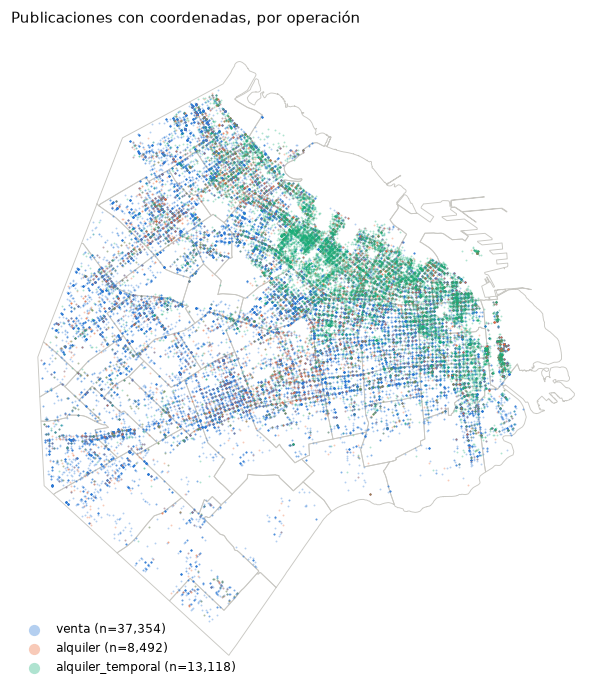

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
for path in [p for paths in barrios['_paths'] for p in paths]:
    v = path.vertices
    ax.plot(v[:, 0], v[:, 1], color='#c9c8c3', lw=0.6, zorder=1)
for op, color in COLORES_OPERACION.items():
    d = ubicacion[(ubicacion['tipo_operacion_norm'] == op) & ubicacion['coords_en_caba']]
    ax.scatter(d['lon'], d['lat'], s=1.5, color=color, alpha=0.35, linewidths=0, label=f'{op} (n={len(d):,})', zorder=2)
ax.set_aspect(1 / np.cos(np.radians(-34.6)))
ax.set_axis_off()
ax.legend(loc='lower left', markerscale=6, frameon=False, fontsize=8)
ax.set_title('Publicaciones con coordenadas, por operación', loc='left', fontsize=10, color='#0b0b0b')
plt.tight_layout()
plt.show()

**Lectura.** El mapa funciona como control visual de la geocodificación: los puntos caen dentro del contorno de la Ciudad y reproducen la geografía conocida de la oferta, con concentración en el corredor norte (Palermo, Belgrano, Recoleta, Núñez) y en el centro, y menor densidad en el sur. El alquiler temporario se concentra todavía más en el norte y el centro. Esto es una descripción de la oferta publicada, no una prueba de hipótesis.

In [12]:
cols_ubicacion = CLAVE + ['fuente_norm', 'lat', 'lon', 'metodo_geo', 'coords_en_caba', 'barrio_oficial',
                          'origen_barrio', 'comuna_oficial', 'estado_barrio_texto', 'fuera_de_caba_flag']
ubicacion[cols_ubicacion].to_csv(config.PROCESSED_DIR / 'publicaciones_ubicacion_v1.csv', index=False)
print('Guardado publicaciones_ubicacion_v1.csv', ubicacion[cols_ubicacion].shape)

Guardado publicaciones_ubicacion_v1.csv (67887, 12)


## 7. Contexto urbano por barrio

Para cada barrio se cuentan los puntos de cada fuente y se calcula su densidad por km² (KPI "Densidad de servicios s en el barrio b"). Para espacios verdes se agrega el porcentaje de la superficie del barrio cubierta por plazas, parques y jardines.

**Sobre índices compuestos.** La versión anterior construía cinco índices (promedio de rankings percentiles de varias densidades). No se incluyen: la consigna pide no incorporar índices sin justificar componentes, escalas y pesos, y promediar percentiles asume implícitamente pesos iguales y equivalencia entre, por ejemplo, una estación de tren y una de MetroBus. Las densidades se reportan por separado; si en la Entrega 3 se necesita una síntesis, se construirá con PCA sobre estas variables, con pesos explícitos.

In [13]:
contexto_barrio = F.contexto_por_barrio(barrios, {k: v for k, v in fuentes.items()})
display(contexto_barrio.sort_values('densidad_culturales_km2', ascending=False).head(10).round(2))
contexto_barrio.to_csv(config.PROCESSED_DIR / 'features_contextuales_barrio_v1.csv', index=False)

ceros = (contexto_barrio.filter(like='n_') == 0).sum().rename('barrios_sin_ningun_punto').to_frame()
display(ceros)

,barrio_oficial,comuna,area_km2,n_subte,densidad_subte_km2,n_tren,densidad_tren_km2,n_metrobus,densidad_metrobus_km2,n_hospitales,densidad_hospitales_km2,n_educacion,densidad_educacion_km2,n_culturales,densidad_culturales_km2,n_gastronomia,densidad_gastronomia_km2,n_espacios_verdes,densidad_espacios_verdes_km2,pct_superficie_verde
31,San Nicolas,1,2.29,10,4.37,0,0.00,39,17.04,0,0.00,22,9.61,368,160.77,454,198.34,9,3.93,2.51
16,Monserrat,1,2.20,9,4.09,0,0.00,40,18.19,0,0.00,19,8.64,246,111.89,149,67.77,9,4.09,2.29
32,San Telmo,1,1.23,0,0.00,0,0.00,23,18.66,0,0.00,18,14.61,116,94.14,80,64.92,6,4.87,4.49
2,Balvanera,3,4.34,12,2.76,1,0.23,0,0.00,1,0.23,64,14.74,224,51.59,215,49.51,7,1.61,0.69
27,Recoleta,2,6.43,7,1.09,1,0.16,0,0.00,3,0.47,65,10.10,322,50.05,327,50.83,31,4.82,4.73
1,Almagro,5,4.05,5,1.23,0,0.00,0,0.00,1,0.25,57,14.07,148,36.54,63,15.55,1,0.25,0.19
28,Retiro,1,4.51,4,0.89,3,0.66,23,5.09,0,0.00,23,5.09,156,34.56,109,24.15,34,7.53,2.08
35,Villa Crespo,15,3.62,1,0.28,1,0.28,10,2.77,0,0.00,43,11.89,106,29.31,44,12.17,3,0.83,0.25
8,Chacarita,15,3.12,2,0.64,2,0.64,0,0.00,0,0.00,15,4.81,66,21.18,18,5.78,8,2.57,2.86
6,Boedo,5,2.61,1,0.38,0,0.00,1,0.38,0,0.00,19,7.28,50,19.16,14,5.36,5,1.92,0.40


,barrios_sin_ningun_punto
n_subte,28
n_tren,21
densidad_tren_km2,21
n_metrobus,15
n_hospitales,29
n_educacion,0
densidad_educacion_km2,0
n_culturales,0
n_gastronomia,1
n_espacios_verdes,0


## 8. Compatibilidad con la unidad de análisis

La consigna pide demostrar que cada fuente es compatible con el alcance: que aporta información al nivel en el que se la va a usar. La medida es qué porcentaje de la variación de la variable derivada ocurre **dentro** de las comunas. El Censo tiene 0% por construcción (un valor por comuna). Una fuente con alta variación intra-comuna permite explicar diferencias entre barrios, o entre viviendas, de una misma comuna.

In [14]:
filas = []
for nombre in ['subte', 'tren', 'metrobus', 'hospitales', 'culturales', 'gastronomia', 'educacion', 'espacios_verdes']:
    filas.append({'fuente': nombre, 'nivel': 'barrio (densidad/km2)',
                  'pct_variacion_intra_comuna': geo.pct_varianza_intra(contexto_barrio, f'densidad_{nombre}_km2', 'comuna')})

pub = ubicacion[ubicacion['coords_en_caba']].copy()
for nombre in ['subte', 'tren', 'metrobus', 'hospitales']:
    pub[f'dist_{nombre}'] = geo.distancia_minima_m(pub['lat'], pub['lon'], fuentes[nombre]['lat'], fuentes[nombre]['lon'])
    filas.append({'fuente': nombre, 'nivel': 'publicación (distancia m)',
                  'pct_variacion_intra_comuna': geo.pct_varianza_intra(pub, f'dist_{nombre}', 'comuna_oficial')})
filas.append({'fuente': 'censo_2022', 'nivel': 'comuna', 'pct_variacion_intra_comuna': 0.0})

compatibilidad = pd.DataFrame(filas)
display(compatibilidad)
compatibilidad.to_csv(config.REPORTS_DIR / 'compatibilidad_fuentes_externas.csv', index=False)

,fuente,nivel,pct_variacion_intra_comuna
0,subte,barrio (densidad/km2),44.4
1,tren,barrio (densidad/km2),69.4
2,metrobus,barrio (densidad/km2),45.9
3,hospitales,barrio (densidad/km2),64.4
4,culturales,barrio (densidad/km2),47.9
5,gastronomia,barrio (densidad/km2),57.7
6,educacion,barrio (densidad/km2),64.5
7,espacios_verdes,barrio (densidad/km2),44.5
8,subte,publicación (distancia m),24.0
9,tren,publicación (distancia m),64.5


**Lectura.** Todas las fuentes puntuales conservan entre un cuarto y dos tercios de su variación dentro de las comunas. A nivel publicación, la distancia al tren, al MetroBus y a hospitales varía más dentro de cada comuna que entre comunas; la distancia al subte es la más ligada a la comuna (24% intra), porque la red se concentra en el centro y el norte. Es decir, dos viviendas de la misma comuna pueden tener entornos muy distintos, y eso solo se captura uniendo por coordenadas o por barrio. El Censo, en cambio, solo permite comparar comunas entre sí.

## 9. Cierre

**Integrado en esta entrega**

| Fuente | Nivel de unión | Salida |
|---|---|---|
| Censo 2022 (6 cuadros) | comuna | `censo_2022_comunas_v1.csv` |
| Subte, tren, MetroBus, hospitales, educación, culturales, gastronomía, verdes | barrio (y publicación, en el notebook 07) | `features_contextuales_barrio_v1.csv` |
| GeoJSON de barrios + USIG | habilitadores | `publicaciones_ubicacion_v1.csv` |
| Dólar MEP | día de extracción | se aplica en el notebook 07 |

**Limitaciones**

1. Las coordenadas de Airbnb están ofuscadas por la plataforma (el punto se desplaza dentro de un radio que puede superar los 100 m), por lo que sus conteos en radio de 500 m tienen ruido; por barrio el efecto es menor.
2. ZonaProp no informa dirección: sus avisos solo se ubican por barrio declarado y no tienen variables de distancia.
3. Las distancias son en línea recta, no caminables.
4. Las fuentes de BA Data son una foto a la fecha de descarga; los avisos son de agosto-septiembre de 2026 y el Censo de 2022.
5. Transporte, cultura y gastronomía están correlacionados con la centralidad: al modelar habrá que controlar por barrio o por distancia al centro para no atribuirles un efecto que es de ubicación.
6. Contar puntos no mide calidad, capacidad ni uso.

**Hallazgos de calidad para corregir aguas arriba (notebook 02)**: el barrio de ArgenProp contiene el nombre de la calle.